# Self-Organizing Maps (SOM)

This notebook presents a complete and reproducible example of a **Self-Organizing Map** using `bluemath_tk`. We will compress a synthetic catalogue of sea states into an ordered two-dimensional grid of representative patterns.

> **Objective:** learn a small map whose neighbouring neurons represent similar sea states, while correctly treating wave direction as a circular variable.

## 1. What is a SOM?

A SOM is an unsupervised neural network that projects multidimensional data onto a usually two-dimensional grid. Each neuron contains a prototype or centroid. During training, an observation selects its **best matching unit** (BMU); that neuron and its neighbours move towards the observation.

This neighbourhood update is what distinguishes a SOM from an ordinary clustering algorithm: the positions on the grid have meaning. Nearby neurons should describe similar conditions, making the result useful for classification, visualization, and selection of representative cases.

In [1]:
import numpy as np
import pandas as pd

from bluemath_tk.datamining.som import SOM
from utils.plotting import plot_som_diagnostics, plot_variable_combinations

## 2. Generate representative sea states

The synthetic catalogue combines three common regimes: locally generated wind sea, moderate swell, and energetic long-period swell. The random generator has a fixed seed so the example is reproducible.

The variables are significant wave height (`Hs`, m), peak period (`Tp`, s), and mean direction (`Dir`, degrees). Direction is wrapped to $[0, 360)$ because $0^\circ$ and $360^\circ$ denote the same direction.

In [2]:
rng = np.random.default_rng(seed=42)
samples_per_regime = 300

regimes = [
    {"Hs": (1.2, 0.35), "Tp": (6.0, 0.8), "Dir": (35, 18)},
    {"Hs": (2.6, 0.45), "Tp": (10.0, 1.0), "Dir": (285, 22)},
    {"Hs": (4.5, 0.65), "Tp": (14.0, 1.1), "Dir": (315, 16)},
    {"Hs": (8.5, 1.25), "Tp": (14.0, 1.1), "Dir": (315, 16)},
]

data = pd.concat(
    [
        pd.DataFrame(
            {
                "Hs": rng.normal(r["Hs"][0], r["Hs"][1], samples_per_regime),
                "Tp": rng.normal(r["Tp"][0], r["Tp"][1], samples_per_regime),
                "Dir": rng.normal(r["Dir"][0], r["Dir"][1], samples_per_regime) % 360,
            }
        )
        for r in regimes
    ],
    ignore_index=True,
)
data["Hs"] = data["Hs"].clip(lower=0.1)
data["Tp"] = data["Tp"].clip(lower=2.0)
data.describe().round(2)

,Hs,Tp,Dir
count,1200.00,1200.00,1200.00
mean,4.20,11.01,239.05
std,2.87,3.49,118.17
min,0.30,3.63,0.03
25%,1.82,7.62,237.60
50%,3.31,11.82,297.78
75%,5.70,14.05,317.10
max,12.32,17.33,359.75


Before training, pairwise plots reveal the regimes and the different numerical ranges of the variables. Notice that a conventional linear plot places directions near $0^\circ$ and $360^\circ$ at opposite ends even though they are physically adjacent; the SOM API handles this circularity during fitting.

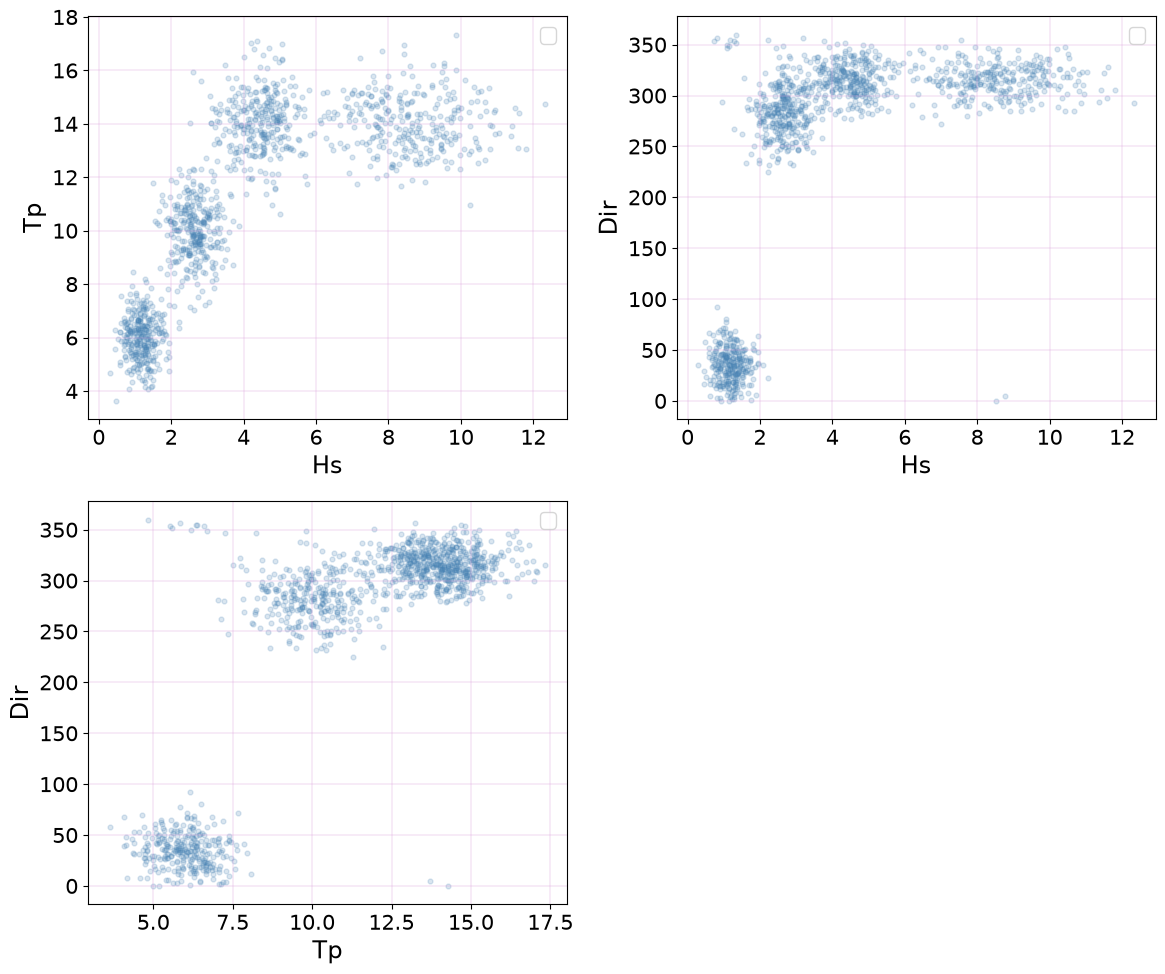

In [3]:
plot_variable_combinations(
    data=data,
    vars=["Hs", "Tp", "Dir"],
    data_color="steelblue",
    size_point=12,
)

## 3. Configure the map

### Arguments used to create `SOM`

- `som_shape=(4, 4)`: creates 16 neurons arranged in four rows and four columns. A larger grid represents more detail but needs more observations and training.
- `num_dimensions=4`: dimensionality seen by the neural network. Although `data` has three columns, the directional variable is converted into two circular components (`Dir_u` and `Dir_v`), so the fitted space contains `Hs`, `Tp`, `Dir_u`, and `Dir_v`.
- `sigma=1.2`: initial radius of neighbourhood influence. A moderately broad radius helps organize adjacent neurons coherently early in training.
- `learning_rate=0.5`: initial size of each weight update. It decays as training progresses.
- `neighborhood_function="gaussian"`: makes the BMU influence nearby neurons smoothly.
- `topology="rectangular"`: defines the geometry used to connect neighbouring neurons.
- `activation_distance="euclidean"`: metric used to select the BMU in the transformed and normalized feature space.
- `random_seed=42`: fixes weight initialization so repeated executions are reproducible.

The omitted decay arguments retain the library defaults, which progressively reduce `sigma` and the learning rate.

In [4]:
som = SOM(
    som_shape=(3, 3),
    num_dimensions=4,
    sigma=1.2,
    learning_rate=0.5,
    neighborhood_function="gaussian",
    topology="rectangular",
    activation_distance="euclidean",
    random_seed=42,
)

## 4. Train the SOM and classify the catalogue

### Arguments used in `fit`

- `data`: numeric `DataFrame` used both to train the map and to find the BMU of every row.
- `directional_variables=["Dir"]`: tells BlueMath to transform this angle into two components. This avoids the artificial discontinuity at north.
- `custom_scale_factor`: physical ranges used for min-max normalization. The directional range is specified for the generated components, not for the original angle. Explicit ranges make the relative influence of the variables transparent.
- `num_iteration=5000`: number of stochastic training updates. More iterations usually improve convergence but increase runtime.
- `normalize_data=True`: puts variables with different units on comparable scales before computing distances.

After fitting, the BMU of every observation is calculated in normalized space. The centroids are also averaged in that space and then transformed back exactly once to the original physical units. This explicit reconstruction works around a `bluemath_tk` issue that otherwise denormalizes already-unscaled centroid values.

In [5]:
scale_ranges = {
    "Hs": [0.0, 8.0],
    "Tp": [3.0, 18.0],
    "Dir_u": [-1.0, 1.0],
    "Dir_v": [-1.0, 1.0],
}

som.fit(
    data=data,
    directional_variables=["Dir"],
    custom_scale_factor=scale_ranges,
    num_iteration=5000,
    normalize_data=True,
)

# Rebuild centroids in normalized space before returning to physical units.
winner_neurons = som._get_winner_neurons(som.normalized_data.values)
som.normalized_centroids = (
    som.normalized_data.assign(winner_neurons=winner_neurons)
    .groupby("winner_neurons")
    .mean()
)
som.centroids = som.denormalize(
    normalized_data=som.normalized_centroids,
    scale_factor=som.scale_factor,
)
som.centroids["Dir"] = som.get_degrees_from_uv(
    xu=som.centroids["Dir_u"].values,
    xv=som.centroids["Dir_v"].values,
)
nearest_centroids = som.centroids.loc[winner_neurons]

print(f"Observations classified: {len(winner_neurons)}")
print(f"Centroids learned: {len(som.centroids)}")
som.centroids.round(2)

Observations classified: 1200
Centroids learned: 9


,Hs,Tp,Dir_u,Dir_v,Dir
winner_neurons,,,,,
0,2.95,10.95,-0.86,0.31,289.67
1,4.92,14.50,-0.81,0.56,304.62
2,7.64,14.21,-0.70,0.69,314.57
3,1.19,6.19,0.27,0.94,16.06
4,5.20,14.01,-0.40,0.90,336.07
5,8.94,13.82,-0.77,0.59,307.41
6,1.19,5.86,0.70,0.69,45.20
7,2.53,9.01,-0.21,0.98,347.96
8,10.11,14.06,-0.60,0.77,321.75


## 5. Inspect the representative patterns

The centroids summarize the catalogue. Their order on the grid is part of the result: gradual changes between neighbouring prototypes indicate that the topology has been learned successfully. The helper below overlays the centroids on every pair of original variables.

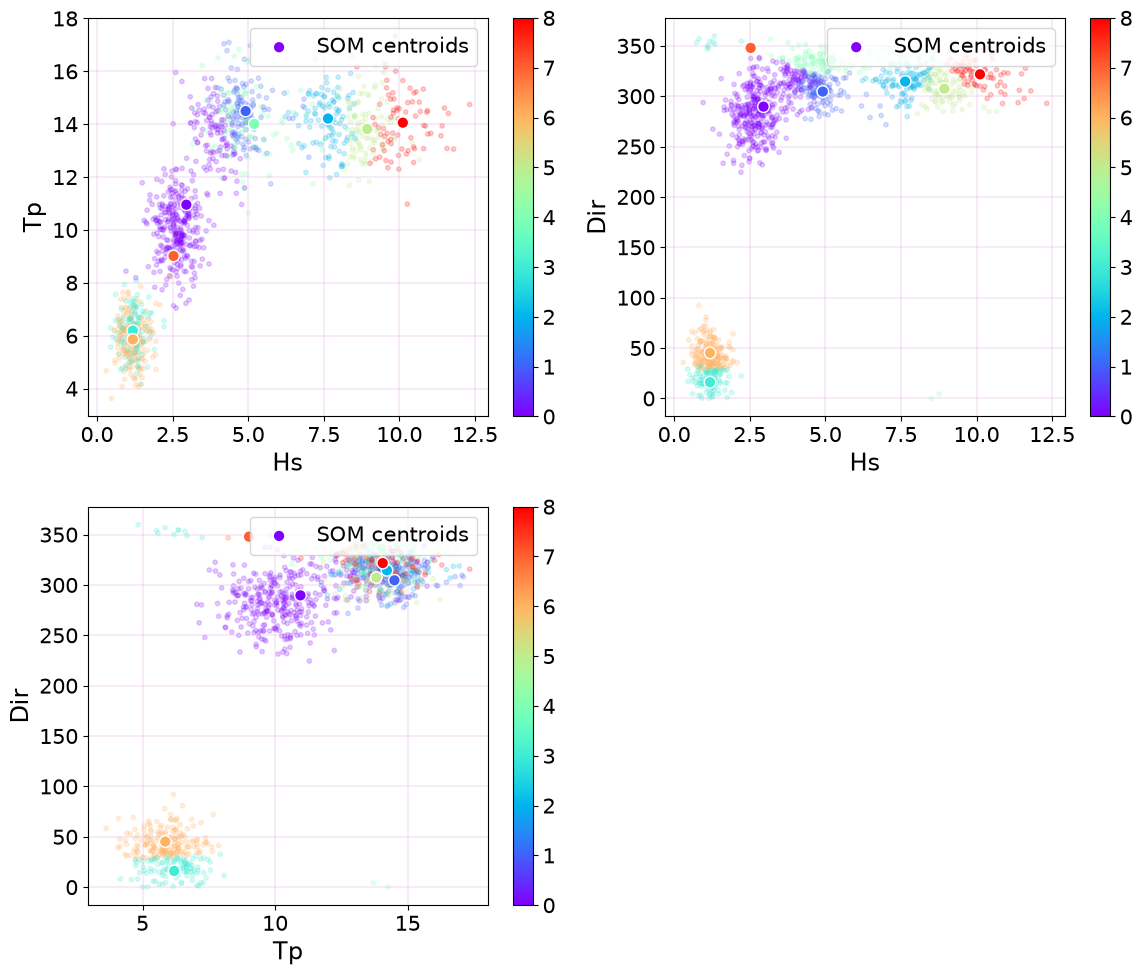

In [6]:
clustered_data = data.assign(cluster=winner_neurons)

plot_variable_combinations(
    data=clustered_data,
    vars=["Hs", "Tp", "Dir"],
    sel_datasets=som.centroids,
    data_color=clustered_data["cluster"],
    sel_color=som.centroids.index.to_numpy(),
    labels="SOM centroids",
    size_point=10,
)

## 6. Diagnose the trained map

Two complementary matrices help interpret the SOM:

- `distance_map`: summarizes distances between neighbouring neuron weights. Dark-to-bright transitions or high values can reveal boundaries between regimes.
- `activation_response(data)`: counts how many observations select each neuron. Empty or scarcely activated neurons may indicate an unnecessarily large map or underrepresented regions. Passing `data` makes explicit which catalogue is being counted.

These diagnostics describe structure and occupancy; neither is, by itself, a universal score of model quality.

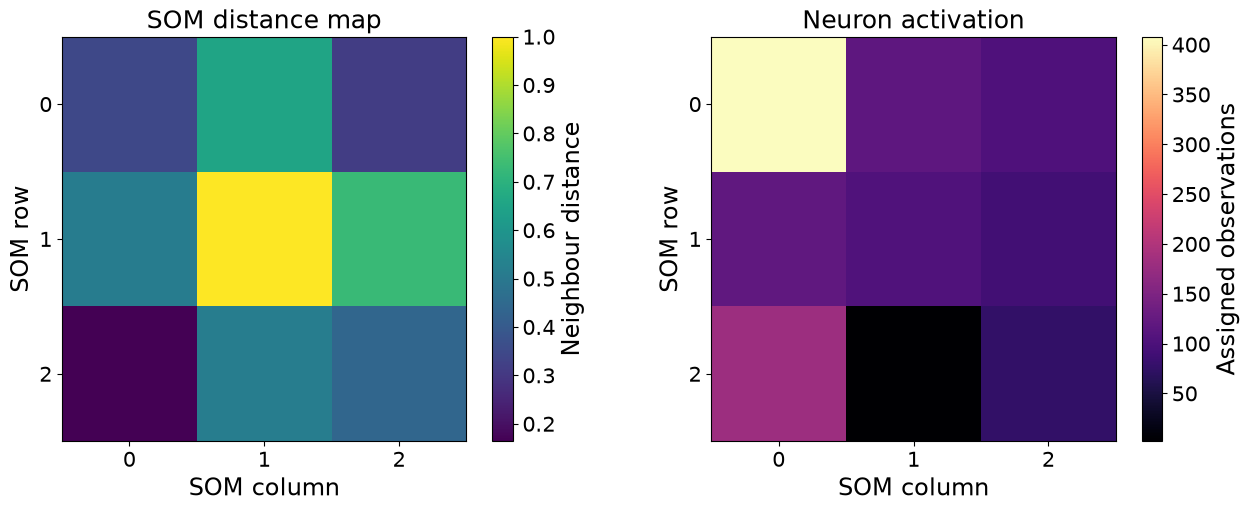

In [7]:
distance_map = som.distance_map
activation_response = som.activation_response()

plot_som_diagnostics(
    distance_map=distance_map,
    activation_response=activation_response,
)

## 7. Assign new sea states

Once fitted, `predict(data)` assigns new observations without retraining the map. The new `DataFrame` must contain the same variables and units used during training. BlueMath reuses the learned transformations and scaling information.

The neuron identifiers locate each BMU, while label-based selection (`loc`) retrieves the corresponding centroid in original physical units.

In [8]:
new_sea_states = pd.DataFrame(
    {
        "Hs": [1.0, 2.8, 5.2],
        "Tp": [5.8, 10.5, 14.8],
        "Dir": [355.0, 280.0, 320.0],
    }
)

normalized_new_data = super(SOM, som).predict(data=new_sea_states)
new_winners = som._get_winner_neurons(normalized_new_data.values)
new_centroids = som.centroids.loc[new_winners].reset_index(drop=True)
assignments = new_sea_states.copy()
assignments["winner_neuron"] = new_winners
assignments = assignments.join(new_centroids.add_prefix("centroid_"))
assignments.round(2)

,Hs,Tp,Dir,winner_neuron,centroid_Hs,centroid_Tp,centroid_Dir_u,centroid_Dir_v,centroid_Dir
0,1.0,5.8,355.0,3,1.19,6.19,0.27,0.94,16.06
1,2.8,10.5,280.0,0,2.95,10.95,-0.86,0.31,289.67
2,5.2,14.8,320.0,1,4.92,14.50,-0.81,0.56,304.62


## 8. Interpretation and next steps

A useful SOM should combine three properties: representative centroids, a gradual organization across neighbouring neurons, and reasonable occupancy. If too many neurons are empty, reduce `som_shape` or increase the training sample and iterations. If distinct regimes blur together, revisit scaling, map size, and `sigma`.

For real applications, also test stability across several seeds and validate the map against physically meaningful labels or independent observations.